In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


Data Framing


In [41]:
data=pd.read_csv("LR/titanic.csv")
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [40]:
print(data.columns)

Index(['cabin', 'sex', 'age', 'survived'], dtype='str')


Exploring Dataset

In [35]:
data = data[["cabin","sex","age","survived"]]
data.shape

(1309, 4)

In [34]:
#Describing our dataset
data.describe()

,cabin,sex,age,survived
count,1309.000000,1309.000000,1046.000000,1309.000000
mean,6.729565,0.644003,29.881135,0.381971
std,2.454520,0.478997,14.413500,0.486055
min,0.000000,0.000000,0.166700,0.000000
25%,8.000000,0.000000,21.000000,0.000000
50%,8.000000,1.000000,28.000000,0.000000
75%,8.000000,1.000000,39.000000,1.000000
max,8.000000,1.000000,80.000000,1.000000


In [33]:
data.head()

,cabin,sex,age,survived
0,1,0,29.0000,1.0
1,2,1,0.9167,1.0
2,2,0,2.0000,0.0
3,2,1,30.0000,0.0
4,2,0,25.0000,0.0


In [30]:
#Printing last 5 rows
data.tail()

,cabin,sex,age,survived
1304,8,0,14.5,0.0
1305,8,0,NaN,0.0
1306,8,1,26.5,0.0
1307,8,1,27.0,0.0
1308,8,1,29.0,0.0


Finding NaN Value or Missing Values

In [8]:
#Finding  number of Nan or missing values in all columns
print(data.isna().sum(axis = 0))

# data.isna().sum(axis = 0)   # Nan values in every column
# data.isna().sum(axis = 1)   # Nan values in every row.

cabin       1015
sex            1
age          264
survived       1
dtype: int64


Preprocessing: Dealing with Missing Values

In [9]:
#Dropping Rows with Nan in all provided columns
data = data.dropna(subset=["sex","survived"])

In [10]:
#Again Finding  number of Nan or missing values in all columns
print(data.isna().sum(axis = 0))

cabin       1014
sex            0
age          263
survived       0
dtype: int64


In [ ]:
data.tail()

Preprocessing: Label Encoding

In [11]:
data["sex"] = data["sex"].map({"male":1,"female":0})

data["sex"]


0       0
1       1
2       0
3       1
4       0
       ..
1304    0
1305    0
1306    1
1307    1
1308    1
Name: sex, Length: 1309, dtype: int64

In [43]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,21,female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,23,male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,24,female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,25,male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,26,female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Features Extraction

In [44]:
features = data[["sex","age","cabin"]]
target = data["survived"]
features.head()

,sex,age,cabin
0,female,29.0000,B5
1,male,0.9167,C22 C26
2,female,2.0000,C22 C26
3,male,30.0000,C22 C26
4,female,25.0000,C22 C26


In [23]:
target.head()

0    1.0
1    1.0
2    0.0
3    0.0
4    0.0
Name: survived, dtype: float64

Preprocessing: Imputation | Missing Values in Age

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
features = imputer.fit_transform(features)

In [25]:
features

array([[ 0.    , 29.    ,  1.    ],
       [ 1.    ,  0.9167,  2.    ],
       [ 0.    ,  2.    ,  2.    ],
       ...,
       [ 1.    , 26.5   ,  8.    ],
       [ 1.    , 27.    ,  8.    ],
       [ 1.    , 29.    ,  8.    ]], shape=(1309, 3))

Splitting our dataset into Train & Test Set

In [26]:
feature_train, feature_test, target_train, target_test = train_test_split(features,target)

Training the Model

In [27]:
model = LogisticRegression()
model.fit(feature_train, target_train)
predictions = model.predict(feature_test)

Printing an Error Matrix and Accuracy Score

In [28]:
print(confusion_matrix(target_test,predictions))
print(accuracy_score(target_test,predictions))

[[178  32]
 [ 40  78]]
0.7804878048780488


K-Nearest Neighbors (KNN)
📌 What is KNN?

English:

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a new data point based on the labels of its nearest neighbors.

বাংলা:
KNN হলো একটি supervised machine learning algorithm, যেখানে নতুন ডেটাকে তার কাছের ডেটাগুলোর উপর ভিত্তি করে classify করা হয়।

🎯 Core Idea

👉 “Tell me who your neighbors are, I’ll tell you who you are.”

বাংলা:
👉 “তোমার পাশের ডেটা দেখে তোমাকে চিনব”

⚙️ How KNN Works (Step-by-step)

Choose a value of K (e.g., 3, 5)

Calculate distance between new point and all data points

Select K nearest neighbors

Take majority vote

Geting Started with KNN Classifier

In [45]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

DataFraming

In [46]:
data = pd.read_csv("KNN/credit_data.csv")
data.head(20)

,clientid,income,age,loan,LTI,default
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1
5,6,24904.064140,57.471607,15.498598,0.000622,0
6,7,48430.359613,26.809132,5722.581981,0.118161,0
7,8,24500.141984,32.897548,2971.003310,0.121265,1
8,9,40654.892537,55.496853,4755.825280,0.116980,0
9,10,25075.872771,39.776378,1409.230371,0.056199,0


In [47]:
# A very simple & Logical technique to find total number of defaulters
data.default.sum()

np.int64(283)

In [48]:
#Finding  number of Nan or missing values in all columns
print(data.isna().sum(axis = 0))

# data.isna().sum(axis = 0)   # Nan values in every column
# data.isna().sum(axis = 1)   # Nan values in every row.

clientid    0
income      0
age         0
loan        0
LTI         0
default     0
dtype: int64


Features Extraction

In [49]:
features = data[["income","age","loan"]]
target = data.default

In [51]:
target.head()


0    0
1    0
2    0
3    0
4    1
Name: default, dtype: int64

Graph

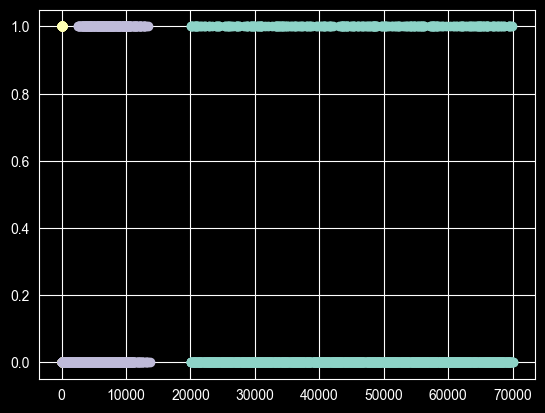

In [52]:

plt.scatter(data.income, data.default)
plt.scatter(data.age, data.default)
plt.scatter(data.loan, data.default)
plt.show()

In [53]:
data.head()
# features.shape
# target.shape

,clientid,income,age,loan,LTI,default
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1


Preprocessing : Standard Scaling

In [54]:
features = preprocessing.MinMaxScaler().fit_transform(features)

feature_train, feature_test, target_train, target_test = train_test_split(features,target)

Training the Model

In [67]:
model = KNeighborsClassifier(n_neighbors=32)
fitModel = model.fit(feature_train, target_train)
predictions = fitModel.predict(feature_test)

In [68]:
cross_valid_scores = []

for k in range(1, 100):
  knn = KNeighborsClassifier(n_neighbors = k)
  scores = cross_val_score(knn,features, target, cv = 10, scoring = 'accuracy')
  cross_valid_scores.append(scores.mean())

print("Optimal k with cross-validation: \t",np.argmax(cross_valid_scores))

Optimal k with cross-validation: 	 32


Printing an Error Matrix and Accuracy Score

In [66]:
print(confusion_matrix(target_test,predictions))
print(accuracy_score(target_test,predictions))

[[428   3]
 [  8  61]]
0.978


<Axes: >

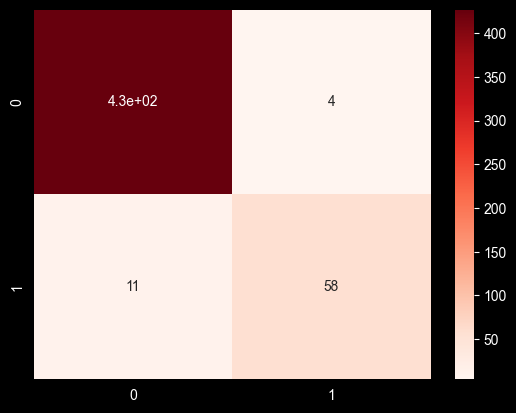

In [72]:
import seaborn as sns
sns.heatmap(confusion_matrix(target_test,predictions), annot=True, cmap='Reds')